In [136]:
from datetime import datetime, time
import pandas as pd
import numpy as np
from itertools import product
from Strategies.Modular_strategy.calibration import ModularStrategyCalibration
from Strategies.Modular_strategy.backtest_class import BacktestModular
from Strategies.Modular_strategy.strategy_class import ModularStrategy
from Strategies.Modular_strategy.strategy_class_new import ModularStrategy as NewStrategy
from Strategies.Sparse_momentum.ob_attributes import OB_attributes, TR_attributes


import pickle
from Strategies.Modular_strategy.features import *
from Strategies.Sparse_momentum.ob_attributes import OB_attributes
from OrderBook.OrderBook import OrderBookSnaps
from SynthSpread.spreadviewer_class import SpreadSingle
from Database.TPData import TPData, TPDataDa
from Utilities.excel_loaders import conn_out_xload
from Utilities.dfutils import date_filter
from Utilities.Storage import get_curr_storage_path

In [137]:
from Database.DB_reader import Database
db = Database('timescaledb')

In [124]:
db.execute_general_query('SELECT * from experimental_predictors')

Connected to the database timescaledb
Disconnected from the database timescaledb


,pred_id,pred_name,main_contract,description,location,prod_strategy,author,additional,created_at
0,obook_delta_a_05_dey1,delta_a_05,dey1,"Order book prediktor, ffillnuty na casy tradov",EnergyTrading\Python\prefect_data_orchestrator...,None,MartinScasny,delty a diff nie su moc okamzite ostatne by ma...,2025-05-12 12:49:54.308737+00:00
1,obook_delta_a_20_dey1,delta_a_20,dey1,"Order book prediktor, ffillnuty na casy tradov",EnergyTrading\Python\prefect_data_orchestrator...,None,MartinScasny,delty a diff nie su moc okamzite ostatne by ma...,2025-05-12 12:49:54.360670+00:00
2,obook_delta_b_05_dey1,delta_b_05,dey1,"Order book prediktor, ffillnuty na casy tradov",EnergyTrading\Python\prefect_data_orchestrator...,None,MartinScasny,delty a diff nie su moc okamzite ostatne by ma...,2025-05-12 12:49:54.396363+00:00
3,obook_delta_b_20_dey1,delta_b_20,dey1,"Order book prediktor, ffillnuty na casy tradov",EnergyTrading\Python\prefect_data_orchestrator...,None,MartinScasny,delty a diff nie su moc okamzite ostatne by ma...,2025-05-12 12:49:54.433457+00:00
4,obook_delta_mid_05_dey1,delta_mid_05,dey1,"Order book prediktor, ffillnuty na casy tradov",EnergyTrading\Python\prefect_data_orchestrator...,None,MartinScasny,delty a diff nie su moc okamzite ostatne by ma...,2025-05-12 12:49:54.463341+00:00
...,...,...,...,...,...,...,...,...,...
93,ll_aux_deq1_dey1_fair_ret,ll_aux_deq1_dey1_fair_ret,dey1,"Fair return developed by Marek, using mid pric...",Projects/EnergyTrading/Python/Strategies/FairP...,,MarekZelenay,None,2025-05-14 14:46:10.729189+00:00
94,ll_aux_dem2_dey1_fair_price,ll_aux_dem2_dey1_fair_price,dey1,"Fair price developed by Marek, using mid price...",Projects/EnergyTrading/Python/Strategies/FairP...,,MarekZelenay,None,2025-05-14 14:46:10.729189+00:00
95,ll_aux_dem2_dey1_fair_ret,ll_aux_dem2_dey1_fair_ret,dey1,"Fair return developed by Marek, using mid pric...",Projects/EnergyTrading/Python/Strategies/FairP...,,MarekZelenay,None,2025-05-14 14:46:10.729189+00:00
96,ll_aux_deq1_dem1_fair_price,ll_aux_deq1_dem1_fair_price,dem1,"Fair price developed by Marek, using mid price...",Projects/EnergyTrading/Python/Strategies/FairP...,,MarekZelenay,None,2025-05-16 10:41:33.689280+00:00


In [ ]:
END_DATE = '2024-09-05'
# Query for 'obook_a_price_dey1'
df_a = db.execute_general_query(
    f"SELECT * FROM public.experimental_dataset_entries WHERE pred_id = 'obook_a_price_dey1' AND datetime < '{END_DATE}'"
)

# Query for 'obook_b_price_dey1'
df_b = db.execute_general_query(
    f"SELECT * FROM public.experimental_dataset_entries WHERE pred_id = 'obook_b_price_dey1' AND datetime < '{END_DATE}'"
)

# Sort both dataframes by 'timestamp'
df_a['timestamp'] = df_a['datetime'] + pd.to_timedelta(df_a['nanotime'], unit='ns')
df_b['timestamp'] = df_b['datetime'] + pd.to_timedelta(df_b['nanotime'], unit='ns')

df_a = df_a.sort_values(by='timestamp')
df_b = df_b.sort_values(by='timestamp')

# Merge the dataframes on 'timestamp'
merged_df = pd.merge(df_b[['timestamp', 'pred_value']], df_a[['timestamp', 'pred_value']], on='timestamp', suffixes=('_b_price', '_a_price'))

# Rename columns for clarity
merged_df.rename(columns={'pred_value_b_price': 'b_price', 'pred_value_a_price': 'a_price'}, inplace=True)

# Drop duplicates based on 'timestamp'
merged_df = merged_df.drop_duplicates(subset='timestamp')

print(merged_df)

Connected to the database timescaledb
Disconnected from the database timescaledb
Connected to the database timescaledb
Disconnected from the database timescaledb
                           timestamp b_price a_price
0      2024-07-01 08:05:02.105774489   88.25    95.0
1      2024-07-01 08:05:08.003636096   89.75   91.65
2      2024-07-01 08:05:08.006713923   89.75   91.65
3      2024-07-01 08:05:11.807488069   89.75   91.65
4      2024-07-01 08:06:23.284000000   89.75   91.65
...                              ...     ...     ...
789813 2024-09-04 18:41:58.803000000    90.0   90.24
789814 2024-09-04 18:44:08.598000000    90.0   90.24
789818 2024-09-04 18:44:35.819000000    90.0   90.24
789819 2024-09-04 18:44:42.944000000    90.0   90.24
789820 2024-09-04 18:44:45.429000000    90.0   90.24

[546259 rows x 3 columns]


In [139]:
merged_df

,timestamp,b_price,a_price
0,2024-07-01 08:05:02.105774489,88.25,95.0
1,2024-07-01 08:05:08.003636096,89.75,91.65
2,2024-07-01 08:05:08.006713923,89.75,91.65
3,2024-07-01 08:05:11.807488069,89.75,91.65
4,2024-07-01 08:06:23.284000000,89.75,91.65
...,...,...,...
789813,2024-09-04 18:41:58.803000000,90.0,90.24
789814,2024-09-04 18:44:08.598000000,90.0,90.24
789818,2024-09-04 18:44:35.819000000,90.0,90.24
789819,2024-09-04 18:44:42.944000000,90.0,90.24


In [32]:
def calc_ev(df_trades):
    bin_edges = np.arange(-1.0, 1.05, 0.05)  # Adding 0.05 to include 1.0 as the
    histograms = []
    for i, row in df_trades.reset_index().iterrows():
        curr_price = row['trd_price']
        try:
            data = df_trades['trd_price'].values[i:i+100]
        except IndexError:
            break
        data = data - curr_price
        counts, _ = np.histogram(data, bins=bin_edges, density=False)
        probabilities = counts / np.sum(counts)
        histograms.append(probabilities)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    EV = [np.sum(bin_centers * probabilities) for probabilities in histograms]

    return EV

In [163]:
# Ensure b_price and a_price are numeric
merged_df['b_price'] = pd.to_numeric(merged_df['b_price'])
merged_df['a_price'] = pd.to_numeric(merged_df['a_price'])

# Calculate the 'mid' column
merged_df['mid'] = 0.5 * (merged_df['b_price'] + merged_df['a_price'])
merged_df['VI_basic'] = merged_df['mid'].rolling(200).std()
merged_df = merged_df.reset_index(drop=True)


In [164]:
window = 400

defined_bins = [-float('inf'), -3, -1.5, -0.49, 0.49, 1.5, 3, float('inf')]
# Labels: 7 labels corresponding to the 7 bins. The central bin gets label 0.
defined_labels = [-3, -2, -1, 0, 1, 2, 3]
num_generated_bins = len(defined_labels) # Should be 7

# Lists to store the distributions (each element will be a Pandas Series of counts)
long_dists_list = []
short_dists_list = []

# Your loop (assuming 'merged_df' is correctly populated and 'window' is set)
i = 0
for row_data in merged_df.to_dict(orient='records'): # Use a different variable name to avoid confusion
    # --- Your calculations for r_long and r_short ---
    # These calculations will be the same in each iteration if merged_df isn't changing based on `row_data`
    # However, `VI` changes, so adjusted returns change.
    r_long = merged_df.loc[i:i+window, 'b_price'] - merged_df.loc[i, 'a_price']
    r_short =  merged_df.loc[i, 'b_price'] - merged_df.loc[i:i+window, 'a_price']
    
    VI = row_data['VI_basic'] # VI from the current row

    # Handle the special case for VI < 0.05
    if VI < 0.05:
        # Append a zero distribution for long, and presumably for short as well?
        # The Series should be indexed by your defined labels.
        zero_distribution = pd.Series(np.zeros(num_generated_bins), index=defined_labels)
        long_dists_list.append(zero_distribution.copy()) # Append a copy
        short_dists_list.append(zero_distribution.copy()) # Assuming same for short
        i += 1
        continue # Skip further processing for this row

    # Calculate adjusted r_long and r_short
    # Adding a small epsilon to VI to prevent division by zero if VI is exactly 0
    adjusted_r_long = r_long / (VI + 1e-9) # Use a very small epsilon
    adjusted_r_short = r_short / (VI + 1e-9)

    # --- Bin the adjusted values ---
    # pd.cut will return a Series of categorical data with your defined_labels
    # include_lowest=True ensures the smallest values are included in the first bin
    binned_long = pd.cut(adjusted_r_long, bins=defined_bins, labels=defined_labels, right=True, include_lowest=True)
    binned_short = pd.cut(adjusted_r_short, bins=defined_bins, labels=defined_labels, right=True, include_lowest=True)

    # --- Calculate the distribution of the bins (counts for each label) ---
    # .value_counts() gives counts for each unique label present.
    # .reindex(defined_labels, fill_value=0) ensures all defined labels are present in the output Series,
    # even if some bins had zero occurrences in this specific `adjusted_r_long/short`.
    long_bin_distribution = binned_long.value_counts().reindex(defined_labels, fill_value=0).sort_index()
    short_bin_distribution = binned_short.value_counts().reindex(defined_labels, fill_value=0).sort_index()

    long_dists_list.append(long_bin_distribution)
    short_dists_list.append(short_bin_distribution)
    i += 1

# --- After the loop, you can aggregate these distributions if needed ---
# For example, to get the total counts for each bin across all rows:
if long_dists_list:
    aggregated_long_distribution = pd.concat(long_dists_list, axis=1).sum(axis=1)
    # Ensure the final index is also your defined_labels and sorted
    aggregated_long_distribution = aggregated_long_distribution.reindex(defined_labels, fill_value=0).sort_index()
else:
    aggregated_long_distribution = pd.Series(np.zeros(num_generated_bins), index=defined_labels)

if short_dists_list:
    aggregated_short_distribution = pd.concat(short_dists_list, axis=1).sum(axis=1)
    aggregated_short_distribution = aggregated_short_distribution.reindex(defined_labels, fill_value=0).sort_index()
else:
    aggregated_short_distribution = pd.Series(np.zeros(num_generated_bins), index=defined_labels)

In [ ]:
long_prob = [(srs_dist/srs_dist.sum()).values[4:].su§m() for srs_dist in long_dists_list]
short_prob = [(srs_dist/srs_dist.sum()).values[4:].sum() for srs_dist in short_dists_list]

<Axes: >

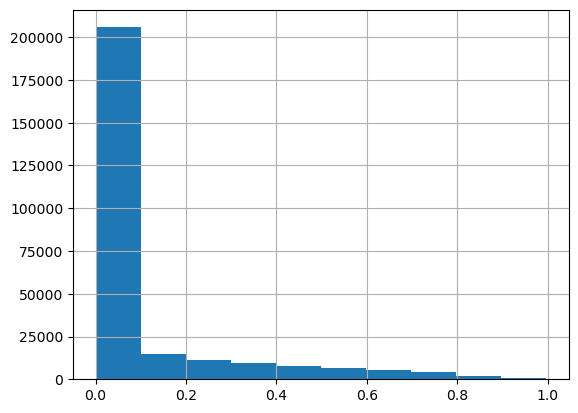

In [234]:
pd.Series(long_ev).hist()

In [232]:
(long_dists_list[10000] / long_dists_list[10000].sum()).values[4:].sum()

0.2718204488778055

In [197]:
np.arange(0, dist.shape[0])[dist == np.median(dist)]

array([2])

In [104]:
# Resample the data to 5-minute candles and take the 'close' price
merged_df['5min_close'] = merged_df.set_index('timestamp')['mid'].resample('5T').last()

# Calculate the rolling standard deviation over 14 candles
merged_df['VI_std'] = merged_df['5min_close'].rolling(window=14).std()

print(merged_df[['timestamp', '5min_close', 'VI_std']])

                          timestamp  5min_close  VI_std
0     2024-07-01 08:05:02.105774489         NaN     NaN
1     2024-07-01 08:05:08.003636096         NaN     NaN
2     2024-07-01 08:05:08.006713923         NaN     NaN
3     2024-07-01 08:05:11.807488069         NaN     NaN
4     2024-07-01 08:06:23.284000000         NaN     NaN
...                             ...         ...     ...
52541 2024-07-04 18:19:53.061000000         NaN     NaN
52542 2024-07-04 18:19:55.811000000         NaN     NaN
52546 2024-07-04 18:35:45.065000000         NaN     NaN
52547 2024-07-04 18:45:55.476000000         NaN     NaN
52548 2024-07-04 18:45:55.507000000         NaN     NaN

[39074 rows x 3 columns]


/var/folders/5t/zn7m2n_95xj1yjfc5dyh8pk80000gn/T/ipykernel_12318/4203697555.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  merged_df['5min_close'] = merged_df.set_index('timestamp')['mid'].resample('5T').last()


In [107]:
merged_df.set_index('timestamp', inplace=True)

### Naive volatility

In [ ]:
merged_df['VI_basic'] = merged_df['mid'].rolling(200).std()

### Load data from datamart to model

In [129]:
PRED_ID_ = 'obook_a_price_dem1'
END_DATE = '2024-09-05'
df_= db.execute_general_query(f"SELECT * from public.experimental_dataset_entries WHERE pred_id = '{PRED_ID_}' AND datetime < '{END_DATE}'")

Connected to the database timescaledb
Disconnected from the database timescaledb


In [130]:
df_

,datetime,nanotime,tradeid,pred_name,pred_id,pred_value,additional,created_at
